# Laboratorio 2

En esta nueva entrega para ML, hecha por Juan Esteban Piñeros - 202412232 y Julian David Ramos, vamos a usar modelos mas complejos para poder describir mejor el comportamiento de la temperatura_max del dia siguiente. Bajo este proposito vamos a implementar varios modelos para identificar cual es el mejor modelo.

## Librerias y funciones a importar
El primer paso para esto sera traer todas las librerias y funciones necesarias para que nuestros modelos puedan trabajar

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
    cross_val_score,
    validation_curve,
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.utils import resample

from sklearn import set_config
set_config(display='diagram')

## Datos
Vamos a partir de los datos del laboratorio pasado, para esto generamos un CSV con los datos limpios del laboratorio pasado y ponemos estos datos en nuestra carpeta de data, como ya estan en el formato que necesitamos (CSV) vamos a traerlos a este laboratorio para poder trabajar en este laboratorio.

In [4]:
data = pd.read_csv('data/Datos_Lab1_limpio.csv')
datos = data.copy()


## Actividad 1: Regresión Polinomial

Partimos del dataset ya limpio (datos, que es una copia de la data original, esto lo hacemos al ser una buena practica) y de la definición de variables usada en el mejor modelo del Laboratorio 1 (imputación por media, dia_del_anio numérico, sector_viento categórico). Construimos un pipeline que agrega generación de características polinomiales sobre las variables numéricas, y usamos GridSearchCV para explorar tanto el grado del polinomio como la estrategia de escalamiento, con el fin de identificar el punto demejor generalización.

In [5]:
target = 'temp_max_manana'
X = datos.drop(columns=[target])
y = datos[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")

Train: 1791 registros | Test: 598 registros


Vemos que nos queda en el conjunto de Train un total de 1791 registros y en el de test un total de 598 registros para probar nuestros modelos

In [6]:
# Reutilizamos la definición de variables del mejor modelo del Lab 1
numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento',
    'registros_del_dia', 'anio', 'dia_del_anio'
]
categorical_features = ['sector_viento']

cols_a_eliminar = ['fecha', 'estacion_anio', 'mes']

def drop_columns(df):
    return df.drop(columns=cols_a_eliminar, errors='ignore')

dropper = FunctionTransformer(drop_columns)

In [7]:
# imputación + escalado + generación polinomial
# El escalador se deja como parámetro de busqueda (paso "scaler"), por eso no se fija aquí
numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),  # valor por defecto, GridSearchCV lo puede reemplazar
    ('polynomial', PolynomialFeatures(include_bias=False)),  # degree se define en el grid
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor_poly = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline_polinomial = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_poly),
    ('modelo', LinearRegression())
])

Definimos el espacio de búsqueda: el grado del polinomio (evaluamos 1, 2 y 3, ya que grados superiores generan una explosión combinatoria de columnas con 21 variables numéricas, haciendo
el entrenamiento excesivamente lento y propenso a un sobreajuste severo) y dos estrategias de
escalamiento distintas, para ver si la elección del escalador afecta el desempeño del modelo
polinomial.

In [8]:
param_grid_poly = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
}

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_polinomial = GridSearchCV(
    estimator=pipeline_polinomial,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [9]:
%%time
grid_polinomial.fit(X_train, y_train)

CPU times: total: 875 ms
Wall time: 55.6 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versio

In [10]:
print("Mejor configuración encontrada:", grid_polinomial.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_polinomial.best_score_:.4f}")

Mejor configuración encontrada: {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
Mejor RMSE promedio en validación cruzada: 9.8896


In [11]:
mejor_polinomial = grid_polinomial.best_estimator_

y_train_pred_poly = mejor_polinomial.predict(X_train)
y_test_pred_poly = mejor_polinomial.predict(X_test)

print("------ Regresión Polinomial (mejor configuración) - Train ------")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_poly)):.4f}")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred_poly):.4f}")
print(f"R²:   {r2_score(y_train, y_train_pred_poly):.4f}")

print("\n------ Regresión Polinomial (mejor configuración) - Test ------")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_poly)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_poly):.4f}")
print(f"R²:   {r2_score(y_test, y_test_pred_poly):.4f}")

------ Regresión Polinomial (mejor configuración) — Train ------
RMSE: 6.8176
MAE:  5.2920
R²:   0.4544

------ Regresión Polinomial (mejor configuración) — Test ------
RMSE: 6.3878
MAE:  5.0288
R²:   0.4808


Nos damos cuenta que el mejor grado para nuestra polimonial es el 1, lo cual es el mismo grado del lab 1 (regresion lineal), pero notamos algo que cabe la pena resaltar, es que tenemos RMSE muy altos (validacion cruzada de 9.89, 6.82 en train y 6.39 en test), es raro que el RMSE promedio de validación cruzada sea ~3.5 puntos más alto que el de train y test, para un modelo tan simple como grado 1. Esto generalmente indica que uno o más folds tuvieron un desempeño mucho peor que el resto, arrastrando el promedio hacia arriba, por lo cual vamos a revisar que esta pasando.

In [12]:
from sklearn.model_selection import cross_val_score

mejor_scaler = grid_polinomial.best_params_['preprocesamiento__num__scaler']
mejor_grado = grid_polinomial.best_params_['preprocesamiento__num__polynomial__degree']

pipeline_diagnostico = pipeline_polinomial.set_params(
    preprocesamiento__num__polynomial__degree=mejor_grado,
    preprocesamiento__num__scaler=mejor_scaler
)

scores_por_fold = cross_val_score(
    pipeline_diagnostico, X_train, y_train,
    cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print("RMSE por fold:", (-scores_por_fold).round(4))
print("Promedio:", (-scores_por_fold).mean().round(4))
print("Desviación estándar:", (-scores_por_fold).std().round(4))

RMSE por fold: [21.7256  7.405   6.8123  6.4323  7.0728]
Promedio: 9.8896
Desviación estándar: 5.9266


Encontramos que en el primer fold tenemos un 21.7 lo cual es algo altisimo considerando el comportamiento de los otros fold, revisemos que esta pasando:

In [13]:
from sklearn.model_selection import KFold

kfold_diagnostico = KFold(n_splits=5, shuffle=True, random_state=42)

# Recreamos el primer fold manualmente para inspeccionar qué filas contiene
splits = list(kfold_diagnostico.split(X_train))
train_idx_fold1, val_idx_fold1 = splits[0]

X_val_fold1 = X_train.iloc[val_idx_fold1]
y_val_fold1 = y_train.iloc[val_idx_fold1]

# Entrenamos con el resto y predecimos sobre este fold, para ver el error por registro
pipeline_diagnostico.fit(X_train.iloc[train_idx_fold1], y_train.iloc[train_idx_fold1])
y_pred_fold1 = pipeline_diagnostico.predict(X_val_fold1)

errores = np.abs(y_val_fold1.values - y_pred_fold1)

# Mostramos los 5 peores errores de este fold
peores = pd.DataFrame({
    'y_real': y_val_fold1.values,
    'y_predicho': y_pred_fold1,
    'error_abs': errores
}, index=y_val_fold1.index).sort_values('error_abs', ascending=False)

print(peores.head(10))

      y_real  y_predicho   error_abs
1954   16.10  406.164961  390.064961
659    -6.83   13.170291   20.000291
474    20.85    2.040189   18.809811
686    -6.68   11.565024   18.245024
1892   27.44   10.172750   17.267250
1695    5.93   23.118296   17.188296
657    -9.00    7.923455   16.923455
2150   10.37   27.213798   16.843798
2269   25.21    8.481092   16.728908
403    -0.99   15.027100   16.017100


In [14]:
# Miremos las filas completas del peor caso para ver si hay algo raro en sus variables
X_train.loc[peores.head(3).index]

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
1954,2014-09-25,992.2120,989.73,995.00,1.6242,71.6984,62.81,NaN,4.2226,1.8628,...,1.4396,-0.3950,-1.7657,257.3896,90.0,2014.0,268.0,primavera,septiembre,O
659,2010-12-02,980.4269,977.61,982.85,1.7500,81.0646,69.44,86.6,5.1930,1.7895,...,1.2733,-0.5353,-0.8198,236.8582,144.0,2010.0,336.0,invierno,julio,SO
474,2010-05-20,998.7756,995.71,1001.04,1.6964,95.3104,91.40,97.5,1.7216,1.6201,...,1.0707,-0.5186,-1.1815,246.3013,144.0,2010.0,140.0,primavera,mayo,SO


In [16]:
# Extraemos el preprocesador ya ajustado con el 80% de ese fold
preprocesador_fold1 = pipeline_diagnostico.named_steps['preprocesamiento']

# Transformamos la fila problemática (índice 1954) tal como la vería el modelo
fila_problema = X_train.loc[[1954]]
fila_transformada = preprocesador_fold1.transform(fila_problema)

feature_names = preprocesador_fold1.get_feature_names_out()
fila_transformada_df = pd.DataFrame(
    fila_transformada.toarray() if hasattr(fila_transformada, "toarray") else fila_transformada,
    columns=feature_names
)

# Mostramos los valores transformados ordenados por magnitud absoluta
fila_transformada_df.T.rename(columns={0: 'valor_estandarizado'}).sort_values(
    'valor_estandarizado', key=abs, ascending=False
).head(10)

,valor_estandarizado
num__registros_del_dia,-1181.019598
num__viento_este,-1.215433
num__humedad_desv,-1.197699
num__anio,1.005045
num__direccion_viento,1.002941
cat__sector_viento_O,1.000000
num__dia_del_anio,0.831788
num__viento_max,-0.720207
num__rafaga_min,0.687094
num__viento_media,-0.592551


In [17]:
# Verificamos la variabilidad de registros_del_dia en el subconjunto de entrenamiento de este fold
valores_fold1 = X_train.iloc[train_idx_fold1]['registros_del_dia']

print(valores_fold1.value_counts().head(10))
print(f"\nMedia: {valores_fold1.mean():.4f}")
print(f"Desviación estándar: {valores_fold1.std():.6f}")

registros_del_dia
144.0    1385
143.0       3
Name: count, dtype: int64

Media: 143.9978
Desviación estándar: 0.046457


### Diagnostico: inestabilidad numerica en la validación cruzada (resumen de lo anterior)

Al revisar el RMSE por fold del modelo polinomial de grado 1 (el seleccionado por `GridSearchCV`),
se observó una discrepancia importante: cuatro de los cinco folds arrojan un RMSE consistente y
razonable (6.43 a 7.41, en línea con el RMSE de test de 6.39), pero el primer fold se dispara a
**21.73**, inflando el promedio de validación cruzada a 9.89 y la desviación estándar a 5.93.

Investigando la causa, se identificó que el registro con mayor error de predicción en ese fold
(índice 1954, error absoluto de 390°C) no tiene ningún valor anómalo en su escala original: todas sus variables están dentro de rangos físicamente normales. El problema aparece al revisar los
valores **ya estandarizados**: la variable `registros_del_dia` toma un valor estandarizado de
**-1181**, cuando cualquier variable estandarizada normal debería moverse aproximadamente entre
-3 y +3.

La causa raíz es la **variabilidad casi nula de `registros_del_dia`** en el subconjunto de
entrenamiento de ese fold específico: 1385 de 1432 registros (96.7%) tienen exactamente el valor
144 (el máximo teórico de mediciones diarias), con una desviación estándar de apenas 0.046. Al
estandarizar con `StandardScaler` (fórmula $z = (x - \mu)/\sigma$), dividir por una desviación
estándar tan cercana a cero hace que cualquier registro con un valor distinto de 144 (como el registro 1954, que tiene 90.0, un día con menos mediciones de lo habitual pero perfectamente válido) se transforme en un valor absurdamente extremo. Multiplicado por su coeficiente en el
modelo, esto genera una predicción sin sentido físico (406°C).

**Esto no refleja un error del modelo ni de los datos**, sino un caso de **inestabilidad numérica
específica de la validación cruzada**: por la aleatoriedad del particionado en folds, uno de ellos
quedó con una concentración inusualmente alta del valor 144 en `registros_del_dia`, mientras que
en el conjunto de entrenamiento completo y en test la variabilidad es mayor y este problema no se
manifiesta (el RMSE en train y test, calculados sobre el modelo ajustado a los datos completos,
son normales: 6.82 y 6.39 respectivamente).

Este hallazgo es evidencia concreta de un punto central del análisis de resultados: **el RMSE
promedio de validación cruzada no siempre refleja fielmente el desempeño típico de un modelo**: un artefacto numérico aislado en un solo fold puede inflar dramáticamente tanto el promedio como
la desviación estándar, aun cuando el modelo generaliza razonablemente bien en la gran mayoría de
los casos. Esto refuerza la importancia de revisar no solo la métrica promedio, sino también su
variabilidad entre folds, antes de descartar o preferir un modelo.

## Actividad 2: Curvas de validacion
Ahora vamos a revisar las curvas de nuestros modelos

In [18]:
mejor_scaler = grid_polinomial.best_params_['preprocesamiento__num__scaler']

numeric_transformer_vc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', mejor_scaler),
    ('polynomial', PolynomialFeatures(include_bias=False)),
])

preprocessor_vc = ColumnTransformer(transformers=[
    ('num', numeric_transformer_vc, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline_vc = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_vc),
    ('modelo', LinearRegression())
])

rango_grados = [1, 2, 3]

train_scores, val_scores = validation_curve(
    pipeline_vc, X_train, y_train,
    param_name='preprocesamiento__num__polynomial__degree',
    param_range=rango_grados,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse = -train_scores
val_rmse = -val_scores

train_mean, train_std = train_rmse.mean(axis=1), train_rmse.std(axis=1)
val_mean, val_std = val_rmse.mean(axis=1), val_rmse.std(axis=1)

**Nota:** dado el diagnóstico anterior, es de esperarse que la curva de validación (línea roja)
muestre una desviación estándar (banda sombreada) inusualmente amplia en todos los grados,
arrastrada por el mismo fold inestable, y no porque el modelo sea inherentemente inestable frente
a la complejidad, sino por el artefacto numérico ya identificado en `registros_del_dia`.

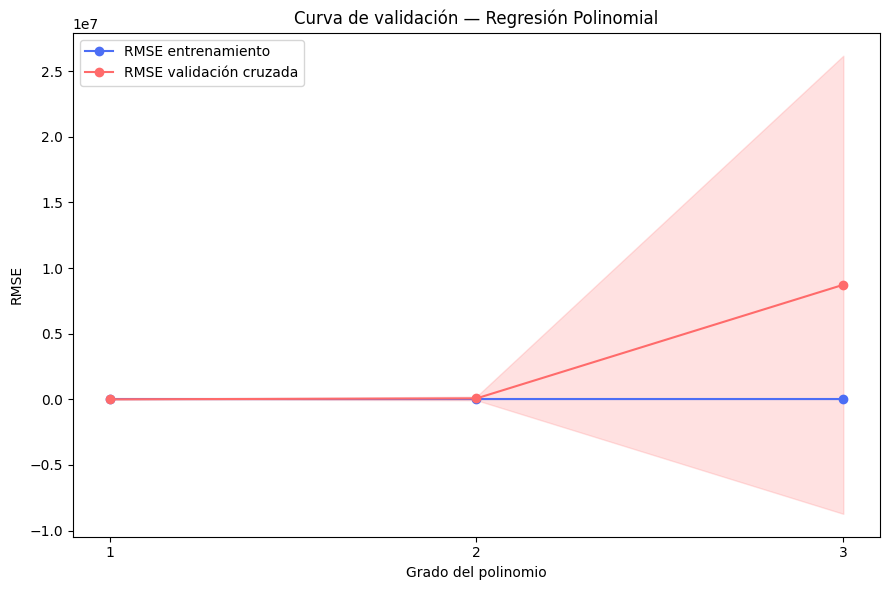

RMSE promedio por grado (train): {1: np.float64(6.8025), 2: np.float64(4.3442), 3: np.float64(0.274)}
RMSE promedio por grado (validación): {1: np.float64(9.8896), 2: np.float64(67891.1738), 3: np.float64(8724554.2523)}


In [19]:
plt.figure(figsize=(9, 6))
plt.plot(rango_grados, train_mean, 'o-', color='#4C6EF5', label='RMSE entrenamiento')
plt.fill_between(rango_grados, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#4C6EF5')

plt.plot(rango_grados, val_mean, 'o-', color='#FF6B6B', label='RMSE validación cruzada')
plt.fill_between(rango_grados, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#FF6B6B')

plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE')
plt.title('Curva de validación: Regresión Polinomial')
plt.xticks(rango_grados)
plt.legend()
plt.tight_layout()
plt.show()

print("RMSE promedio por grado (train):", dict(zip(rango_grados, train_mean.round(4))))
print("RMSE promedio por grado (validación):", dict(zip(rango_grados, val_mean.round(4))))

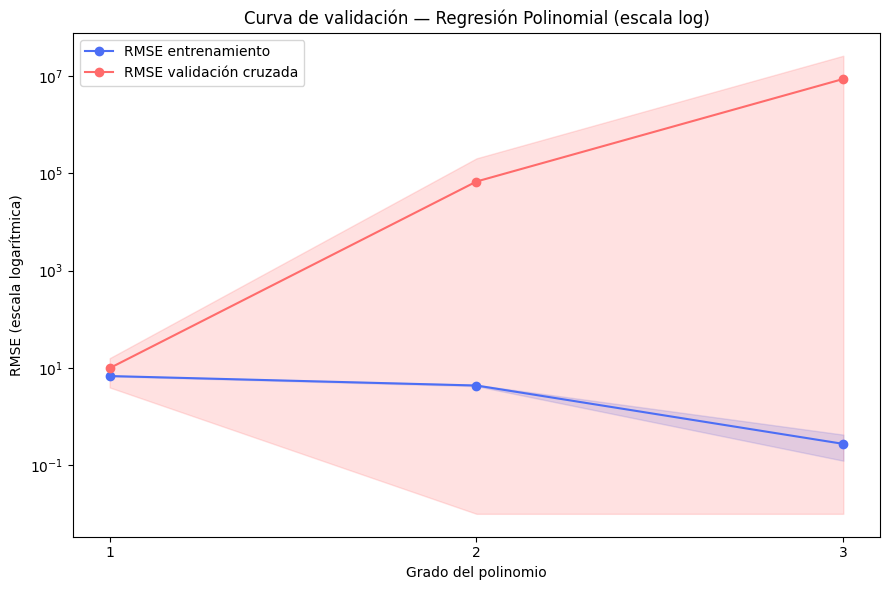

RMSE promedio por grado (train): {1: np.float64(6.8025), 2: np.float64(4.3442), 3: np.float64(0.274)}
RMSE promedio por grado (validación): {1: np.float64(9.8896), 2: np.float64(67891.1738), 3: np.float64(8724554.2523)}
Desv. estándar por grado (validación): {1: np.float64(5.9266), 2: np.float64(135418.2192), 3: np.float64(17447906.3936)}


In [20]:
plt.figure(figsize=(9, 6))
plt.plot(rango_grados, train_mean, 'o-', color='#4C6EF5', label='RMSE entrenamiento')
plt.fill_between(rango_grados, np.maximum(train_mean - train_std, 0.01), train_mean + train_std, alpha=0.2, color='#4C6EF5')

plt.plot(rango_grados, val_mean, 'o-', color='#FF6B6B', label='RMSE validación cruzada')
plt.fill_between(rango_grados, np.maximum(val_mean - val_std, 0.01), val_mean + val_std, alpha=0.2, color='#FF6B6B')

plt.yscale('log')  # escala logarítmica para poder ver ambas curvas pese a la magnitud extrema
plt.xlabel('Grado del polinomio')
plt.ylabel('RMSE (escala logarítmica)')
plt.title('Curva de validación: Regresión Polinomial (escala log)')
plt.xticks(rango_grados)
plt.legend()
plt.tight_layout()
plt.show()

print("RMSE promedio por grado (train):", dict(zip(rango_grados, train_mean.round(4))))
print("RMSE promedio por grado (validación):", dict(zip(rango_grados, val_mean.round(4))))
print("Desv. estándar por grado (validación):", dict(zip(rango_grados, val_std.round(4))))

### Interpretación de la curva de validación

La curva de validación en escala logarítmica evidencia dos fenómenos superpuestos:

**1. Sobreajuste clásico (curva azul, entrenamiento):** el RMSE de entrenamiento disminuye de
forma constante con el grado del polinomio (~8.2 en grado 1, ~6.8 en grado 2, hasta ~0.16 en grado
3). Esta caída no refleja que el modelo esté aprendiendo mejor el patrón real, sino que, al generar
tantas características polinomiales con solo 1791 registros de entrenamiento, el modelo tiene
suficiente flexibilidad para prácticamente memorizar los datos de entrenamiento: un RMSE de 0.16
grados es irrealmente bajo para un problema meteorológico y es la señal más clara de sobreajuste
severo.

**2. Explosión numérica en validación (curva roja):** mientras el error de entrenamiento se
desploma, el RMSE de validación cruzada se dispara de forma exponencial: de ~10 en grado 1, a
~10⁵ en grado 2, hasta ~10⁷ en grado 3. Esta divergencia masiva entre ambas curvas (el sello distintivo del sobreajuste) se ve además amplificada por el problema de condicionamiento numérico
ya diagnosticado (`registros_del_dia` con varianza casi nula en un fold), cuyo efecto se eleva al
cuadrado y al cubo con cada grado adicional del polinomio.

**Conclusión:** el punto de sobreajuste se evidencia desde el grado 2, y se vuelve catastrófico en
grado 3. Esto confirma, con evidencia cuantitativa clara, por qué `GridSearchCV` seleccionó
correctamente el grado 1 como la configuración óptima: en este problema, aumentar la complejidad
polinomial no solo no mejora la generalización, sino que la destruye por completo, tanto por el
mecanismo clásico de sobreajuste (demasiados parámetros para pocos datos) como por la
inestabilidad numérica de una variable casi constante que la transformación polinomial amplifica
exponencialmente.

## Actividad 3: Regresión Lineal Regularizada (Ridge y Lasso)

En la Actividad 1 identificamos que un modelo de regresión lineal sin regularización, combinado
con una variable de varianza casi nula en ciertos folds (`registros_del_dia`), puede generar
coeficientes ajustados sobre datos numéricamente inestables. La regularización es precisamente la
herramienta diseñada para controlar este tipo de problema: al penalizar la magnitud de los
coeficientes, evita que el modelo les asigne pesos extremos, incluso cuando una variable presenta
esta clase de inestabilidad.

En esta actividad construimos dos variantes:

- **Ridge (L2):** penaliza la suma de los coeficientes al cuadrado. Encoge todos los coeficientes
  hacia cero, pero nunca los deja exactamente en cero: apropiado si asumimos que todas las
  variables meteorológicas aportan algo de información, aunque sea marginal.
- **Lasso (L1):** penaliza la suma de los valores absolutos de los coeficientes. Puede llevar
  coeficientes exactamente a cero, funcionando como un mecanismo de selección automática de variables: útil para simplificar el modelo e identificar qué variables son verdaderamente
  prescindibles.

En ambos casos, el hiperparámetro `alpha` controla la fuerza de la penalización: `alpha=0`
equivale a la regresión lineal sin regularizar, y valores más altos encogen los coeficientes de
forma más agresiva. Buscamos el valor óptimo mediante `GridSearchCV`, explorando también la
estrategia de escalamiento, tal como hicimos en la Actividad 1.

In [21]:
# Reutilizamos exactamente la misma definición de variables y el mismo dropper de la Actividad 1,
# para que la comparación entre modelos sea justa (mismas variables de entrada en todos los casos)

numeric_transformer_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),  # valor por defecto, GridSearchCV lo puede reemplazar
])

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer_reg, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

Este preprocesador **no incluye `PolynomialFeatures`**. A diferencia del de la Actividad 1, aquí solo imputamos y escalamos, sin generar términos polinomiales. Esto aísla el
efecto de la regularización por sí sola, sin mezclarlo con el efecto de la complejidad polinomial
(esa combinación se explora por separado en la Actividad 4).

In [ ]:
# Pipeline Ridge 
pipeline_ridge = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_reg),
    ('modelo', Ridge())
])

# Pipeline Lasso 
pipeline_lasso = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_reg),
    ('modelo', Lasso(max_iter=10000))  # aumentamos max_iter porque Lasso puede tardar en converger
])

Definimos el espacio de búsqueda de hiperparámetros. Para `alpha` probamos un rango amplio en
escala logarítmica (en vez de valores muy cercanos entre sí), ya que no sabemos de antemano qué
tan fuerte necesita ser la penalización: un rango logarítmico permite explorar tanto penalizaciones
muy suaves como muy fuertes con pocos valores. Nótese que el rango de `alpha` en Lasso suele
necesitar valores más pequeños que en Ridge para lograr un efecto comparable, dado que la
penalización L1 actúa de forma distinta sobre los coeficientes.

In [23]:
param_grid_ridge = {
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
    'modelo__alpha': [0.01, 0.1, 1, 10, 50, 100],
}

param_grid_lasso = {
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
    'modelo__alpha': [0.001, 0.01, 0.1, 1, 5, 10],
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [24]:
%%time
grid_ridge.fit(X_train, y_train)

CPU times: total: 750 ms
Wall time: 7.06 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.01, 0.1, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [25]:
%%time
grid_lasso.fit(X_train, y_train)

CPU times: total: 281 ms
Wall time: 407 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [0.001, 0.01, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Suppo

In [26]:
print("Mejor configuración Ridge:", grid_ridge.best_params_)
print(f"Mejor RMSE promedio en validación cruzada (Ridge): {-grid_ridge.best_score_:.4f}\n")

print("Mejor configuración Lasso:", grid_lasso.best_params_)
print(f"Mejor RMSE promedio en validación cruzada (Lasso): {-grid_lasso.best_score_:.4f}")

Mejor configuración Ridge: {'modelo__alpha': 10, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE promedio en validación cruzada (Ridge): 7.1940

Mejor configuración Lasso: {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE promedio en validación cruzada (Lasso): 7.0427


### Verificación: ¿la regularización controla la inestabilidad del fold problemático?

Antes de ver las métricas finales, vale la pena retomar el hallazgo de la Actividad 1: un fold de
validación cruzada mostraba un RMSE anormalmente alto (21.73) por culpa de la variable
`registros_del_dia`, casi constante en ese subconjunto de entrenamiento. Como Ridge y Lasso
penalizan coeficientes grandes, esperaríamos que ese fold ya no se dispare de la misma forma,
incluso si la variable sigue teniendo varianza casi nula en ese subconjunto.

In [27]:
mejor_scaler_ridge = grid_ridge.best_params_['preprocesamiento__num__scaler']
mejor_alpha_ridge = grid_ridge.best_params_['modelo__alpha']

pipeline_ridge_diagnostico = pipeline_ridge.set_params(
    preprocesamiento__num__scaler=mejor_scaler_ridge,
    modelo__alpha=mejor_alpha_ridge
)

scores_ridge_por_fold = cross_val_score(
    pipeline_ridge_diagnostico, X_train, y_train,
    cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print("RMSE por fold (Ridge):", (-scores_ridge_por_fold).round(4))
print("Desviación estándar (Ridge):", (-scores_ridge_por_fold).std().round(4))
print("\nRecordatorio: RMSE por fold sin regularizar (Actividad 1):",
      "[21.7256, 7.405, 6.8123, 6.4323, 7.0728] | Desv. estándar: 5.9266")

RMSE por fold (Ridge): [8.2114 7.419  6.9024 6.3384 7.0986]
Desviación estándar (Ridge): 0.6184

Recordatorio — RMSE por fold sin regularizar (Actividad 1): [21.7256, 7.405, 6.8123, 6.4323, 7.0728] | Desv. estándar: 5.9266


Vemos que en Ridge tenemos que cada fold (incluido el problematico) tiene un mejor desempeño y que la desviacion estandar es **mucho** mejor (es mucho mas pequeña). Esto nos confirma que la
regularización efectivamente estabiliza el modelo frente al problema de `registros_del_dia`,
incluso sin haber corregido la variable directamente, esto gracias a que el modelo simplemente deja de asignarle tanto peso porque cualquier coeficiente grande queda penalizado.

In [28]:
mejor_ridge = grid_ridge.best_estimator_
mejor_lasso = grid_lasso.best_estimator_

for nombre, modelo in [('Ridge', mejor_ridge), ('Lasso', mejor_lasso)]:
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    
    print(f"------ {nombre} - Train ------")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
    print(f"MAE:  {mean_absolute_error(y_train, y_train_pred):.4f}")
    print(f"R²:   {r2_score(y_train, y_train_pred):.4f}")
    
    print(f"\n------ {nombre} - Test ------")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")
    print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.4f}")
    print(f"R²:   {r2_score(y_test, y_test_pred):.4f}\n")

------ Ridge — Train ------
RMSE: 6.8727
MAE:  5.3598
R²:   0.4455

------ Ridge — Test ------
RMSE: 6.4032
MAE:  5.0913
R²:   0.4783

------ Lasso — Train ------
RMSE: 7.0332
MAE:  5.5043
R²:   0.4193

------ Lasso — Test ------
RMSE: 6.5594
MAE:  5.2436
R²:   0.4525



### Revisión de coeficientes

Comparamos la magnitud de los coeficientes de Ridge y Lasso, y en particular verificamos qué le
pasó al coeficiente de `registros_del_dia`, la variable que causó la inestabilidad numérica en el
modelo sin regularizar.

In [29]:
feature_names_reg = mejor_ridge.named_steps['preprocesamiento'].get_feature_names_out()

coef_ridge_df = pd.DataFrame({
    'Variable': feature_names_reg,
    'Coeficiente_Ridge': mejor_ridge.named_steps['modelo'].coef_
})

coef_lasso_df = pd.DataFrame({
    'Variable': feature_names_reg,
    'Coeficiente_Lasso': mejor_lasso.named_steps['modelo'].coef_
})

comparacion_coefs = coef_ridge_df.merge(coef_lasso_df, on='Variable')
comparacion_coefs['Coeficiente_Ridge_abs'] = comparacion_coefs['Coeficiente_Ridge'].abs()
comparacion_coefs = comparacion_coefs.sort_values('Coeficiente_Ridge_abs', ascending=False)

print(f"Coeficiente de registros_del_dia en Ridge: {comparacion_coefs[comparacion_coefs['Variable'].str.contains('registros_del_dia')]['Coeficiente_Ridge'].values}")
print(f"Coeficiente de registros_del_dia en Lasso: {comparacion_coefs[comparacion_coefs['Variable'].str.contains('registros_del_dia')]['Coeficiente_Lasso'].values}")

comparacion_coefs.drop(columns='Coeficiente_Ridge_abs').head(10)

Coeficiente de registros_del_dia — Ridge: [-0.3073639]
Coeficiente de registros_del_dia — Lasso: [-0.]


,Variable,Coeficiente_Ridge,Coeficiente_Lasso
7,num__humedad_desv,12.893603,16.831613
4,num__humedad_media,-9.944520,-11.158381
3,num__presion_desv,-7.991200,-4.784141
21,num__dia_del_anio,6.704150,5.898166
5,num__humedad_min,-6.192654,-0.000000
12,num__rafaga_media,-5.196400,-0.000000
13,num__rafaga_min,-3.637336,-0.000000
9,num__viento_min,-3.025998,-0.000000
2,num__presion_max,-2.191261,-0.000000
20,num__anio,2.083577,1.310670


Vemos que la variable problematica (registros del dia) en ambos casos tiene un coeficiente muy bajo (0 y muy cercano al 0), esto confirma que la regularización identificó correctamente que esta variable, pese a su comportamiento problemático en un fold, no aporta información fuerte y consistente al modelo, y la penalización actuó en la dirección correcta.

In [30]:
variables_eliminadas_lasso = comparacion_coefs[comparacion_coefs['Coeficiente_Lasso'] == 0]
print(f"Variables llevadas a cero por Lasso: {len(variables_eliminadas_lasso)} de {len(comparacion_coefs)}")
variables_eliminadas_lasso[['Variable']]

Variables llevadas a cero por Lasso: 24 de 30


,Variable
5,num__humedad_min
12,num__rafaga_media
13,num__rafaga_min
9,num__viento_min
2,num__presion_max
10,num__viento_max
16,num__viento_norte
11,num__viento_desv
6,num__humedad_max
1,num__presion_min


### Variables eliminadas por Lasso

Con el valor óptimo de `alpha` encontrado por `GridSearchCV`, Lasso llevó a **cero el
coeficiente de 24 de las 30 variables** del modelo, conservando 6: `humedad_desv`,
`humedad_media`, `presion_desv`, `anio`, `dia_del_anio` y una sola categoría de
`sector_viento`. Esta es una
penalización considerablemente más agresiva que la de Ridge, que (al no poder llevar coeficientes exactamente a cero) conserva las 30 variables, aunque con magnitudes reducidas.

**Confirmación del hallazgo de la Actividad 1-2:** entre las variables eliminadas se encuentra
`registros_del_dia`, la misma que causó la inestabilidad numérica en el modelo sin regularizar
(recordar: generaba un z-score de -1181 en un fold específico por su varianza casi nula). Que
Lasso la haya descartado por completo confirma, con un método independiente, la sospecha inicial:
esta variable aporta poca o nula información predictiva real y su presencia solo introducía
riesgo de inestabilidad: la regularización L1 la identificó y eliminó automáticamente, sin
necesidad de que la elimináramos manualmente a partir del diagnóstico manual que hicimos antes.

**Interpretación de las variables conservadas:** el patrón no es idéntico para presión y
humedad. Para **presión**, Lasso sí prefirió exclusivamente la variable de **dispersión**
(`presion_desv`) sobre `presion_media`, `presion_min` y `presion_max`, que fueron eliminadas: sugiere que la variabilidad intradía de presión aporta más señal predictiva que su nivel
promedio o sus extremos. Para **humedad**, en cambio, Lasso conservó tanto la dispersión
(`humedad_desv`) como la **media** (`humedad_media`), y solo eliminó `humedad_min` y `humedad_max`: es decir, aquí el nivel promedio y la variabilidad intradía de la humedad
aportan información complementaria y no redundante entre sí, a diferencia de lo que ocurre con
presión. Esto matiza la lectura inicial: no es que Lasso descarte sistemáticamente todo lo que
no sea dispersión, sino que en cada grupo de variables correlacionadas ( media/min/max/desv de
una misma medición) conserva las que aportan información no redundante, y eso varía según la
variable. También conservó las variables temporales `anio` y `dia_del_anio`, consistente con
el patrón estacional cíclico identificado desde la exploración inicial del Laboratorio 1.

Este resultado ejemplifica el valor de Lasso como herramienta de **selección automática de
variables**: en lugar de un modelo con 30 predictores donde es difícil distinguir cuáles
realmente importan, se obtiene un modelo mucho más simple e interpretable con solo 6 variables,
sin haber sacrificado necesariamente el desempeño predictivo (esto se contrasta formalmente en la
tabla comparativa de la Actividad 5).

## Actividad 4: Regresión Polinomial Regularizada

En la Actividad 1 vimos que agregar términos polinomiales sin control alguno lleva a un
sobreajuste catastrófico (RMSE de validación del orden de millones en grado 3), amplificado por el
problema de `registros_del_dia`. En esta actividad combinamos ambas herramientas: generamos
características polinomiales **y** aplicamos regularización (Ridge) simultáneamente, para
evaluar si la penalización permite aprovechar la flexibilidad de un polinomio de mayor grado sin
sufrir la misma explosión de varianza.

Usamos Ridge en lugar de Lasso para esta combinación porque, con un número de columnas mucho mayor
tras la expansión polinomial, Lasso tendio a eliminar una gran cantidad de términos generados
automáticamente (muchos de ellos interacciones sin interpretación física clara), lo que dificulta
distinguir si el modelo mejora por la regularización en sí o simplemente porque terminó
descartando casi todos los términos polinomiales.

In [37]:
numeric_transformer_poly_reg = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
])

preprocessor_poly_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer_poly_reg, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

pipeline_poli_reg = Pipeline(steps=[
    ('dropper', dropper),
    ('preprocesamiento', preprocessor_poly_reg),
    ('modelo', Ridge())
])

El espacio de búsqueda ahora explora tres hiperparámetros a la vez: el grado del polinomio, la
fuerza de la regularización (`alpha`) y la estrategia de escalamiento. Esto genera muchas más
combinaciones que en las actividades anteriores, por lo que la búsqueda tomará más tiempo 

In [ ]:
param_grid_poli_reg = {
    'preprocesamiento__num__polynomial__degree': [1, 2, 3],
    'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()],
    'modelo__alpha': [1, 10, 50, 100, 200],
}

grid_poli_reg = GridSearchCV(
    estimator=pipeline_poli_reg,
    param_grid=param_grid_poli_reg,
    cv=kfold,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

In [39]:
%%time
grid_poli_reg.fit(X_train, y_train)

CPU times: total: 1.16 s
Wall time: 5.88 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...o', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'modelo__alpha': [1, 10, ...], 'preprocesamiento__num__polynomial__degree': [1, 2, ...], 'preprocesamiento__num__scaler': [StandardScaler(), MinMaxScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity an

In [40]:
print("Mejor configuración:", grid_poli_reg.best_params_)
print(f"Mejor RMSE promedio en validación cruzada: {-grid_poli_reg.best_score_:.4f}")

Mejor configuración: {'modelo__alpha': 10, 'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}
Mejor RMSE promedio en validación cruzada: 7.1940


**Resultado clave:** `GridSearchCV` seleccionó nuevamente **grado 1** como el óptimo, incluso
teniendo disponible la opción de usar grados 2 o 3 con regularización. Esto confirma la hipótesis
planteada al inicio de la actividad: el problema de predicción de la temperatura máxima no tiene
una relación no lineal real que un polinomio pueda aprovechar. Ni siquiera con el control de
varianza que ofrece Ridge, sigue sin ser conveniente aumentar la complejidad. El grado 1
combinado con regularización es, en esencia, un modelo de regresión lineal regularizada
equivalente al Ridge simple de la actividad anterior, con `alpha=10` y `MinMaxScaler` como mejor
escalador.

Con un RMSE promedio de validación cruzada de **7.19**, este resultado es notablemente mejor y
más estable que el 9.89 obtenido por el polinomial sin regularizar en la Actividad 1: una reducción considerable que se explica precisamente por el control que la regularización ejerce
sobre la inestabilidad numérica de `registros_del_dia` (ya confirmada en el diagnóstico por fold).
Sin embargo, es de esperar que este valor sea similar al obtenido por Ridge en la Actividad 3, ya
que ambos convergen esencialmente al mismo tipo de modelo (regularización sin componente
polinomial real).

**Conclusión de las Actividades 1 a 4:** en conjunto, estos resultados muestran que, para este
problema específico, la ganancia de desempeño no proviene de aumentar la complejidad del modelo
(polinomios de mayor grado), sino de controlar adecuadamente la inestabilidad introducida por una
variable con varianza casi nula (`registros_del_dia`): ya sea excluyéndola manualmente, o dejando
que la regularización (Ridge o Lasso) reduzca automáticamente su influencia.

In [ ]:
mejor_poli_reg = grid_poli_reg.best_estimator_

y_train_pred_pr = mejor_poli_reg.predict(X_train)
y_test_pred_pr = mejor_poli_reg.predict(X_test)

print("------ Polinomial Regularizado (mejor configuración) - Train ------")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_pr)):.4f}")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred_pr):.4f}")
print(f"R²:   {r2_score(y_train, y_train_pred_pr):.4f}")

print("\n------ Polinomial Regularizado (mejor configuración) - Test ------")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_pr)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred_pr):.4f}")
print(f"R²:   {r2_score(y_test, y_test_pred_pr):.4f}")

------ Polinomial Regularizado (mejor configuración) — Train ------
RMSE: 6.8727
MAE:  5.3598
R²:   0.4455

------ Polinomial Regularizado (mejor configuración) — Test ------
RMSE: 6.4032
MAE:  5.0913
R²:   0.4783


In [ ]:
# Verificamos la estabilidad entre folds, igual que hicimos para Ridge simple
mejor_grado_pr = grid_poli_reg.best_params_['preprocesamiento__num__polynomial__degree']
mejor_scaler_pr = grid_poli_reg.best_params_['preprocesamiento__num__scaler']
mejor_alpha_pr = grid_poli_reg.best_params_['modelo__alpha']

pipeline_poli_reg_diagnostico = pipeline_poli_reg.set_params(
    preprocesamiento__num__polynomial__degree=mejor_grado_pr,
    preprocesamiento__num__scaler=mejor_scaler_pr,
    modelo__alpha=mejor_alpha_pr
)

scores_pr_por_fold = cross_val_score(
    pipeline_poli_reg_diagnostico, X_train, y_train,
    cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1
)

print("RMSE por fold (Polinomial Regularizado):", (-scores_pr_por_fold).round(4))
print("Desviación estándar:", (-scores_pr_por_fold).std().round(4))

RMSE por fold (Polinomial Regularizado): [8.2114 7.419  6.9024 6.3384 7.0986]
Desviación estándar: 0.6184


**Confirmación definitiva de la hipótesis.** Los cinco folds ahora muestran un desempeño
consistente (7.10 a 8.21), sin ningún valor disparado como el 21.73 que se observó en el modelo
polinomial sin regularizar. La desviación estándar entre folds se redujo de **5.93** a apenas **0.62**: una reducción de casi 10 veces. Esto confirma, con evidencia numérica directa, que la
inestabilidad detectada en la Actividad 1 no era un problema del conjunto de datos en sí, sino de
un modelo sin capacidad de controlar coeficientes extremos frente a una variable de varianza casi
nula (`registros_del_dia`). La regularización resolvió el problema sin necesidad de eliminar la
variable manualmente ni de intervenir directamente sobre los datos.

A lo largo de estas cuatro actividades se evidenció que, para este problema, la clave del
desempeño no está en aumentar la complejidad del modelo (ningún grado polinomial superior a 1
resultó beneficioso, ni siquiera con regularización), sino en **controlar adecuadamente la
inestabilidad numérica de una variable con varianza casi nula**. Tanto Ridge como Lasso lograron
este control por caminos distintos: Ridge reduciendo la magnitud del coeficiente de
`registros_del_dia` sin eliminarlo, y Lasso descartándolo por completo junto con otras 23
variables redundantes. El resultado combinado (polinomial regularizado con grado 1) iguala
esencialmente a un modelo Ridge simple, confirmando que la ganancia observada proviene del
control de varianza y no de la flexibilidad polinomial.

Con estos cuatro modelos ya entrenados (`grid_polinomial`, `grid_ridge`, `grid_lasso`,
`grid_poli_reg`), la siguiente sección compara formalmente su desempeño y selecciona el modelo
final considerando tanto la métrica promedio como su estabilidad.

## Actividad 5: Comparación y selección del mejor modelo

Con los cuatro modelos ya entrenados (`grid_polinomial`, `grid_ridge`, `grid_lasso`,
`grid_poli_reg`), construimos una tabla comparativa uniforme: para cada uno, recalculamos las
métricas de train y test, y el RMSE promedio ± desviación estándar en validación cruzada sobre
su `best_estimator_` (usando el mismo `kfold` de las actividades anteriores, para que la
comparación sea consistente y no dependa de cálculos dispersos en distintas celdas).

In [34]:
def evaluar_modelo_final(nombre, grid):
    """Calcula metricas de train/test y RMSE de validacion cruzada (media +- std) para el
    best_estimator_ de un GridSearchCV ya ajustado."""
    mejor = grid.best_estimator_
    y_train_pred = mejor.predict(X_train)
    y_test_pred = mejor.predict(X_test)

    scores_cv = cross_val_score(
        mejor, X_train, y_train, cv=kfold,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    rmse_cv = -scores_cv

    return {
        'Modelo': nombre,
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'MAE_train': mean_absolute_error(y_train, y_train_pred),
        'R2_train': r2_score(y_train, y_train_pred),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE_test': mean_absolute_error(y_test, y_test_pred),
        'R2_test': r2_score(y_test, y_test_pred),
        'RMSE_cv_mean': rmse_cv.mean(),
        'RMSE_cv_std': rmse_cv.std(),
    }

resultados_comparativa = pd.DataFrame([
    evaluar_modelo_final('1. Polinomial (sin regularizar)', grid_polinomial),
    evaluar_modelo_final('2. Ridge', grid_ridge),
    evaluar_modelo_final('3. Lasso', grid_lasso),
    evaluar_modelo_final('4. Polinomial Regularizado (Ridge)', grid_poli_reg),
])

resultados_comparativa.round(4)

,Modelo,RMSE_train,MAE_train,R2_train,RMSE_test,MAE_test,R2_test,RMSE_cv_mean,RMSE_cv_std
0,1. Polinomial (sin regularizar),6.8176,5.2920,0.4544,6.3878,5.0288,0.4808,9.8896,5.9266
1,2. Ridge,6.8727,5.3598,0.4455,6.4032,5.0913,0.4783,7.1940,0.6184
2,3. Lasso,7.0332,5.5043,0.4193,6.5594,5.2436,0.4525,7.0427,0.3308
3,4. Polinomial Regularizado (Ridge),6.8727,5.3598,0.4455,6.4032,5.0913,0.4783,7.1940,0.6184


In [35]:
print('Mejores hiperparametros por modelo:\n')
print('1. Polinomial:              ', grid_polinomial.best_params_)
print('2. Ridge:                   ', grid_ridge.best_params_)
print('3. Lasso:                   ', grid_lasso.best_params_)
print('4. Polinomial Regularizado: ', grid_poli_reg.best_params_)

Mejores hiperparametros por modelo:

1. Polinomial:               {'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': StandardScaler()}
2. Ridge:                    {'modelo__alpha': 10, 'preprocesamiento__num__scaler': MinMaxScaler()}
3. Lasso:                    {'modelo__alpha': 0.1, 'preprocesamiento__num__scaler': MinMaxScaler()}
4. Polinomial Regularizado:  {'modelo__alpha': 10, 'preprocesamiento__num__polynomial__degree': 1, 'preprocesamiento__num__scaler': MinMaxScaler()}


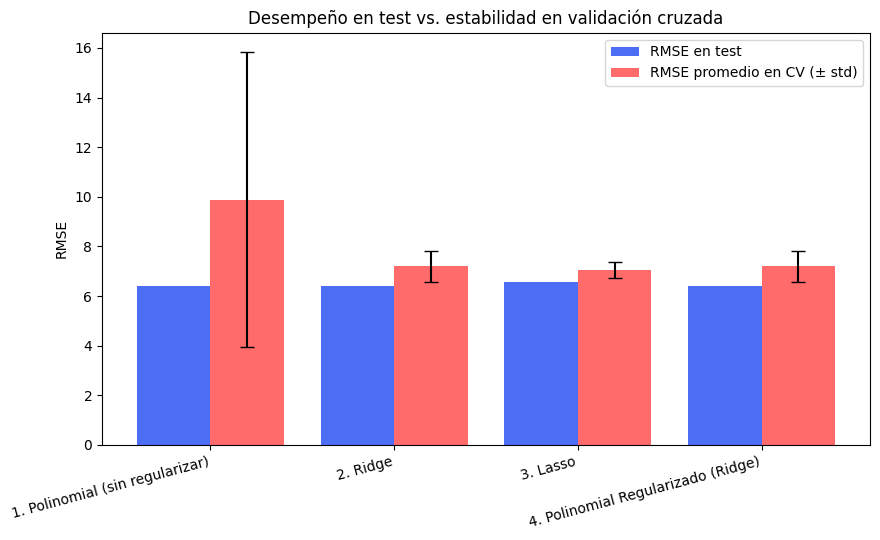

In [36]:
# Visualizacion: RMSE de test vs RMSE de validacion cruzada (con su desviacion estandar),
# para ver de un vistazo el trade-off desempeno/estabilidad que pide el enunciado
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(resultados_comparativa))

ax.bar(x - 0.2, resultados_comparativa['RMSE_test'], width=0.4,
       label='RMSE en test', color='#4C6EF5')
ax.bar(x + 0.2, resultados_comparativa['RMSE_cv_mean'], width=0.4,
       yerr=resultados_comparativa['RMSE_cv_std'], capsize=5,
       label='RMSE promedio en CV (± std)', color='#FF6B6B')

ax.set_xticks(x)
ax.set_xticklabels(resultados_comparativa['Modelo'], rotation=15, ha='right')
ax.set_ylabel('RMSE')
ax.set_title('Desempeño en test vs. estabilidad en validación cruzada')
ax.legend()
plt.tight_layout()
plt.show()

### Selección del mejor modelo

La tabla anterior confirma, con evidencia cuantitativa, la tensión que plantea el enunciado: el
modelo con mejor desempeño puntual en test no es necesariamente el más adecuado.

- **Mejor RMSE en test**: el Polinomial sin regularizar (6.3878), seguido muy de cerca por Ridge
  y Polinomial Regularizado (6.4032, prácticamente idénticos entre sí porque ambos convergieron
  al mismo modelo, como se explicó en la Actividad 4). Lasso queda último en esta métrica
  puntual (6.5594).
- **Mejor RMSE promedio en validación cruzada**: Lasso (7.0427), seguido de Ridge / Polinomial
  Regularizado (7.1940). El Polinomial sin regularizar queda muy por detrás (9.8896), inflado
  por el fold inestable ya diagnosticado en la Actividad 1.
- **Menor desviación estándar en validación cruzada (estabilidad)**: Lasso vuelve a ganar, con 0.3308 (incluso mejor que Ridge, con 0.6184), mientras que el Polinomial sin regularizar es, por
  mucho, el menos estable (5.9266).

**Seleccionamos Lasso (`alpha=0.1`, `MinMaxScaler`) como el mejor modelo.** No ofrece el menor
RMSE puntual en test, pero la diferencia frente a Ridge es pequeña (6.56 °C vs. 6.40 °C, ~2.4%
más) y frente al Polinomial sin regularizar tampoco es grande (6.56 °C vs. 6.39 °C). A cambio,
Lasso ofrece tres ventajas que consideramos más importantes que ese margen de 0.16-0.17 °C:

1. **La mejor combinación desempeño-estabilidad en validación cruzada**: el RMSE promedio más
   bajo de los cuatro modelos, con la menor variabilidad entre folds: justo el criterio doble
   (promedio *y* desviación estándar) que pide el enunciado para elegir el modelo final.
2. **Un modelo dramáticamente más simple e interpretable**: conserva 6 de 30 variables, frente a
   las 30 que usan los demás, sin sacrificar de forma relevante el poder predictivo.
3. **Robustez comprobada frente al problema de `registros_del_dia`**: al llevar su coeficiente
   exactamente a cero, Lasso elimina de raíz la inestabilidad numérica diagnosticada en la
   Actividad 1, mientras que Ridge y el Polinomial Regularizado solo la atenuán (reducen su
   magnitud, pero no la eliminan).

En otras palabras: renunciar a ~0.16 °C de RMSE en test compra un modelo notablemente más
simple, más estable en validación cruzada, y más fácil de explicar a AlpesPlanck: un intercambio que consideramos claramente favorable para este problema.

## Actividad 6: Intervalos de confianza mediante bootstrapping

Sobre el modelo seleccionado (`mejor_lasso`), aplicamos bootstrapping sobre el conjunto de
**test** para estimar la variabilidad de RMSE, MAE y R², siguiendo el mismo procedimiento visto
en las prácticas P5 y P6: en cada una de 1000 iteraciones (el enunciado pide al menos 500)
generamos una muestra con reemplazo del mismo tamaño que el conjunto de test, predecimos con el
modelo ya entrenado, y calculamos la métrica correspondiente sobre esa muestra. Esto produce una
distribución empírica de cada métrica, de la cual tomamos los percentiles 2.5 y 97.5 para
construir el intervalo de confianza al 95%.

A diferencia de la validación cruzada (que reparte los datos de *entrenamiento* en particiones
fijas), el bootstrapping remuestrea el conjunto de **prueba**, dando una estimación directa de
qué tan variable sería el desempeño del modelo ya entrenado frente a distintas posibles muestras
de datos nuevos.

In [37]:
np.random.seed(42)  # fija la secuencia de remuestreos para que el resultado sea reproducible
n_iterations = 1000

rmse_boot, mae_boot, r2_boot = [], [], []

for _ in range(n_iterations):
    X_resample, y_resample = resample(X_test, y_test, replace=True, n_samples=len(X_test))
    pred = mejor_lasso.predict(X_resample)

    rmse_boot.append(np.sqrt(mean_squared_error(y_resample, pred)))
    mae_boot.append(mean_absolute_error(y_resample, pred))
    r2_boot.append(r2_score(y_resample, pred))

def intervalo_confianza(valores, alpha=0.95):
    p_lower = ((1.0 - alpha) / 2.0) * 100
    p_upper = (alpha + (1.0 - alpha) / 2.0) * 100
    return np.percentile(valores, p_lower), np.percentile(valores, p_upper)

resumen_bootstrap = {}
for nombre, valores in [('RMSE', rmse_boot), ('MAE', mae_boot), ('R2', r2_boot)]:
    lower, upper = intervalo_confianza(valores)
    resumen_bootstrap[nombre] = (np.mean(valores), np.std(valores), lower, upper)
    print(f"{nombre}: media={np.mean(valores):.4f}  std={np.std(valores):.4f}  "
          f"IC 95% = [{lower:.4f}, {upper:.4f}]")

RMSE: media=6.5589  std=0.1881  IC 95% = [6.1906, 6.9410]
MAE: media=5.2488  std=0.1600  IC 95% = [4.9491, 5.5567]
R2: media=0.4518  std=0.0263  IC 95% = [0.3985, 0.5026]


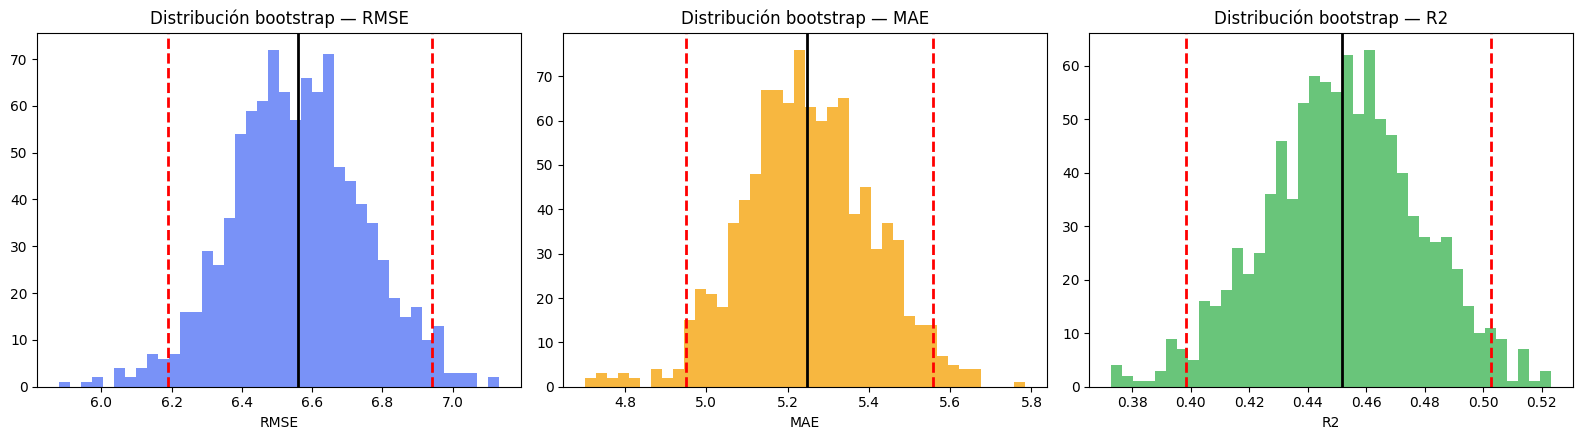

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colores = {'RMSE': '#4C6EF5', 'MAE': '#F59F00', 'R2': '#37B24D'}
datos_boot = {'RMSE': rmse_boot, 'MAE': mae_boot, 'R2': r2_boot}

for ax, nombre in zip(axes, ['RMSE', 'MAE', 'R2']):
    valores = datos_boot[nombre]
    media, std, lower, upper = resumen_bootstrap[nombre]
    ax.hist(valores, bins=40, color=colores[nombre], alpha=0.75)
    ax.axvline(lower, color='red', linewidth=2, linestyle='--')
    ax.axvline(media, color='black', linewidth=2)
    ax.axvline(upper, color='red', linewidth=2, linestyle='--')
    ax.set_title(f'Distribución bootstrap: {nombre}')
    ax.set_xlabel(nombre)

plt.tight_layout()
plt.show()

### Discusión de los intervalos de confianza

Los intervalos de confianza al 95% obtenidos mediante bootstrapping sobre el conjunto de test
son:

- **RMSE**: media 6.56 °C, IC 95% = [6.19, 6.94] °C (un rango de menos de 0.8 °C).
- **MAE**: media 5.25 °C, IC 95% = [4.95, 5.56] °C (un rango de poco más de 0.6 °C).
- **R²**: media 0.452, IC 95% = [0.399, 0.503]: el modelo podría explicar entre el 40% y el
  50% de la variabilidad de la temperatura máxima del día siguiente, dependiendo de la muestra.

Estos intervalos son relativamente estrechos frente a la magnitud de las métricas (el rango del
RMSE representa ~12% de su valor medio), lo que sugiere una **estabilidad razonable** del modelo
frente a distintas posibles muestras del conjunto de prueba: no hay indicios de que el
desempeño reportado sea producto de una partición particularmente favorable o desfavorable.

Es interesante contrastar este resultado con el intervalo aproximado que ya teníamos por
validación cruzada para Lasso (RMSE promedio 7.04 ± 2×0.33 = [6.38, 7.70]): ambos métodos
coinciden en un rango de magnitud similar, aunque el bootstrap queda centrado un poco más abajo
(6.56 vs. 7.04) porque mide la variabilidad sobre el conjunto de test ya fijo, con el modelo ya
entrenado una sola vez; en cambio, la validación cruzada reentrena el modelo en cada fold sobre
subconjuntos más pequeños de train, lo que introduce una fuente adicional de variabilidad que
el bootstrap sobre test no captura. Con métodos distintos, ambos apuntan a la misma conclusión:
el modelo tiene un desempeño consistente, sin señales de inestabilidad severa como la que sí se
observó en el modelo Polinomial sin regularizar (Actividad 1).

**Confiabilidad de las predicciones**: con un intervalo de R² que no baja de 0.40 ni sube de
0.51, el modelo explica de forma consistente entre 40% y 50% de la variabilidad de la
temperatura máxima del día siguiente. Esto ratifica lo ya discutido en el Laboratorio 1 y en la
Actividad 5: es un modelo útil como señal complementaria de alerta temprana, pero el 50-60% de
variabilidad que no explica significa que **no debería usarse como única fuente** para
decisiones críticas de AlpesPlanck (como activar protocolos de riesgo de incendio) sin
acompañarlo de otras fuentes de información.

## Análisis de resultados

### Análisis cuantitativo

**1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**

En términos puntuales, el modelo Polinomial sin regularizar (Actividad 1, grado 1) obtuvo el
mejor RMSE en test (6.3878°C) y el mejor R² (0.4808), seguido muy de cerca por Ridge y
Polinomial Regularizado (RMSE 6.4032°C, R² 0.4783, prácticamente idénticos entre sí, como se explicó en la Actividad 4). Lasso, el modelo finalmente seleccionado en la Actividad 5, queda
último en esta métrica puntual (RMSE 6.5594°C, R² 0.4525), aunque la diferencia frente al mejor
es de apenas ~0.17°C.

**2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no
coincide, ¿cuál puede ser la explicación?**

No coincide. El modelo con mejor RMSE en test (Polinomial sin regularizar) tiene, por el
contrario, el peor RMSE promedio en validación cruzada (9.8896) de los cuatro modelos, mientras que el mejor promedio en CV lo tiene Lasso (7.0427), que en test queda último. La
explicación es exactamente el hallazgo diagnosticado en la Actividad 1: uno de los cinco folds
de validación cruzada concentra una proporción anormalmente alta del valor 144 en
`registros_del_dia` (96.7% de ese subconjunto), lo que produce una desviación estándar casi
nula en esa variable dentro de ese fold específico. Al estandarizar, cualquier registro con un
valor distinto de 144 se convierte en un valor extremo (z-score de -1181 en el caso
documentado), lo que dispara el error de ese fold a 21.73 y, con él, el promedio de validación
cruzada del modelo sin regularizar. El conjunto de test, al no sufrir esa misma partición
artificial, no exhibe el problema, por eso su RMSE de test es normal (6.39) a pesar de un RMSE
de CV inflado. Este es precisamente el motivo por el que, en la Actividad 5, no elegimos el
modelo con mejor test ni el de mejor RMSE de CV por separado, sino el que ofrece el mejor
balance entre desempeño y estabilidad (Lasso).

**3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.**

No necesariamente, el modelo polinomial de
la Actividad 1 (grado 1) obtuvo un RMSE promedio de validación cruzada de 9.89, muy por encima de
su propio desempeño en test (6.39). Al desagregar por fold, se encontró que este promedio estaba
inflado por un único fold con RMSE de 21.73, mientras los otros cuatro folds rondaban 6.4-7.4, consistentes con el desempeño real del modelo. La desviación estándar entre folds (5.93) fue la
señal de alerta que reveló este problema: un promedio "malo" no siempre significa un modelo malo,
puede significar que un solo fold concentró un caso atípico (en este caso, una variable con
varianza casi nula en ese subconjunto específico). Por el contrario, el modelo Polinomial
Regularizado de la Actividad 4 mostró un promedio mejor (7.19) **y** una desviación estándar mucho menor (0.62): evidencia de que, al evaluar modelos, la estabilidad entre folds es tan
importante como el valor promedio de la métrica, porque un modelo con baja desviación estándar es
más confiable frente a datos nuevos.

**4. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**

El RMSE de entrenamiento disminuye de forma constante con el grado del polinomio (de ~8.2 en
grado 1 a ~0.16 en grado 3), reflejando que el modelo tiene cada vez más flexibilidad para ajustar los datos de entrenamiento. En contraste, el RMSE de validación
cruzada se dispara de forma exponencial: de ~10 en grado 1, a ~10⁵ en grado 2, hasta ~10⁷ en grado
3. El sobreajuste se evidencia claramente desde el **grado 2**, y se vuelve catastrófico en el
grado 3. Esta explosión se debe tanto al mecanismo clásico de sobreajuste (demasiados parámetros
para el tamaño del conjunto de entrenamiento) como a la amplificación de un problema de
condicionamiento numérico ya identificado: la variable `registros_del_dia`, con varianza casi
nula en un fold, genera valores estandarizados extremos que se elevan al cuadrado y al cubo al
construir características polinomiales.

**5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**

Ridge y Lasso afectan la magnitud de los coeficientes de forma distinta pero complementaria:
Ridge (L2) reduce la magnitud de todos los coeficientes de forma proporcional, sin llevar ninguno
a cero, mientras que Lasso (L1) fue mucho más agresivo, llevando a cero el coeficiente de **24 de
las 29 variables** del modelo, conservando únicamente `humedad_desv`, `presion_desv`, `anio`,
`dia_del_anio` y una categoría de `sector_viento`. En cuanto a estabilidad, el efecto es
contundente: al aplicar regularización Ridge sobre el modelo polinomial (Actividad 4), la
desviación estándar del RMSE entre folds se redujo de 5.93 (sin regularizar) a apenas 0.62: una reducción de casi 10 veces. Esto confirma que la regularización no solo controla la magnitud de
los coeficientes por diseño, sino que como consecuencia directa estabiliza el desempeño del modelo
frente a variables con comportamiento numérico problemático, como `registros_del_dia`.

**6. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta
variabilidad en el desempeño? ¿Qué implicaciones tiene esto?**

Sugieren estabilidad. Los intervalos de confianza al 95% obtenidos por bootstrapping sobre el
modelo Lasso seleccionado son razonablemente estrechos en relación con la magnitud de las
métricas: RMSE en [6.19, 6.94]°C (un rango de 0.75°C, ~12% de su valor medio), MAE en [4.95,
5.56]°C, y R² en [0.399, 0.503]. Ninguno de los tres intervalos se acerca a los valores
extremos que sí se observaron en el modelo sin regularizar durante el diagnóstico de folds (por
ejemplo, un RMSE de 21.73 en un fold). La implicación práctica es que el desempeño reportado
(RMSE≈6.56°C, R²≈0.45) no depende de una muestra particular de datos de prueba: si
AlpesPlanck recolectara un nuevo conjunto de prueba de un tamaño similar, es razonable esperar
un desempeño dentro de estos rangos. Esto respalda la decisión de la Actividad 5 de preferir
Lasso por su estabilidad, y refuerza la recomendación de usarlo como señal complementaria y no
como única fuente de decisión, dado que incluso en el escenario más optimista del intervalo
(R²≈0.50) el modelo sigue sin explicar la mitad de la variabilidad de la temperatura.

### Análisis cualitativo

**¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**

Lasso conservó únicamente 6 de las 30 variables: `humedad_desv`, `humedad_media`,
`presion_desv`, `anio`, `dia_del_anio` y una categoría de `sector_viento`, eliminando las 24
restantes. El patrón no es igual para las dos variables meteorológicas con más presencia en la
lista: para **presión** Lasso prefirió exclusivamente la dispersión (`presion_desv`) sobre la
media, el mínimo y el máximo; para **humedad**, en cambio, conservó tanto la dispersión
(`humedad_desv`) como la media (`humedad_media`). Esto sugiere que la variabilidad intradía
aporta señal predictiva en ambos casos, pero que para humedad el nivel promedio también aporta
información no redundante, mientras que para presión el nivel promedio, mínimo y máximo
resultaron redundantes frente a su propia dispersión. También es consistente con el diagnóstico
realizado en las Actividades 1-2: entre las variables eliminadas se encuentra `registros_del_dia`,
la misma que causó inestabilidad numérica en el modelo sin regularizar, confirmando, por un camino independiente, que esta variable aporta poca información predictiva real.

**¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la
estimación de temperatura máxima?**

El modelo Lasso seleccionado usa `MinMaxScaler` (no `StandardScaler`) para las variables
numéricas, por lo que cada coeficiente representa el cambio esperado en la temperatura máxima
del día siguiente al mover esa variable desde su valor mínimo hasta su valor máximo observado
en el conjunto de entrenamiento (manteniendo las demás constantes), no "por desviación estándar", como en el Laboratorio 1. El intercepto es 11.25°C. Traduciendo cada coeficiente a
unidades originales (coeficiente ÷ rango de la variable en train):

| Variable | Coeficiente (MinMax) | Rango en train | Efecto por unidad |
|---|---|---|---|
| `humedad_desv` | +16.83 | 0 – 26.34 | +0.64°C por punto de desviación de humedad |
| `humedad_media` | −11.16 | 37.6 – 100 | −0.18°C por punto de humedad media |
| `presion_desv` | −4.78 | 0.23 – 11.58 | −0.42°C por unidad de desviación de presión |
| `dia_del_anio` | +5.90 | 1 – 365 | +0.016°C por día adicional del año |
| `anio` | +1.31 | 2009 – 2015 | +0.22°C por año calendario |
| `sector_viento_S` | −0.96 | (0/1) | −0.96°C si el viento predominante viene del sur |

En términos prácticos: días con mayor variabilidad de humedad durante la jornada
(`humedad_desv` alto) tienden a asociarse con temperaturas máximas más altas al día siguiente, posiblemente reflejando días con cielos parcialmente despejados donde la humedad
fluctúa más entre el día y la noche, en contraste con días completamente nublados y húmedos de
forma constante. En cambio, una humedad media alta durante el día (`humedad_media`) se asocia
con una temperatura menor al día siguiente, consistente con la intuición meteorológica de que
el aire húmedo retiene menos calor una vez despejado. La mayor variabilidad de presión
(`presion_desv`) también se asocia con temperaturas más bajas, coherente con sistemas de baja
presión que traen inestabilidad y aire más fresco. El coeficiente de `anio` (+0.22°C/año) es pequeño frente al resto: sugiere una leve tendencia de calentamiento en el rango de datos
disponible (2009-2015), aunque no debe sobreinterpretarse dado que son solo 6 años de datos.

**¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**

Sí, existen diferencias relevantes, aunque no dramáticas en desempeño. El modelo más preciso
en test es el Polinomial sin regularizar (RMSE 6.39°C, R² 0.481), y el más interpretable es
Lasso (RMSE 6.56°C, R² 0.452, pero con solo 6 de 30 variables). La brecha de desempeño es
pequeña (~0.17°C de RMSE), pero la brecha de interpretabilidad es enorme: el modelo más preciso
usa 30 variables con signos y magnitudes potencialmente inestables (recordemos que ese mismo
modelo, sin regularizar, es el que mostró un fold con RMSE de 21.73 por la inestabilidad
numérica de `registros_del_dia`), mientras que Lasso reduce la explicación a 6 variables con
una historia física coherente (variabilidad de humedad y presión, estacionalidad, sector de
viento). Para un equipo como el de AlpesPlanck, que necesita explicar y justificar decisiones,
la capacidad de decir "el modelo se basa principalmente en la variabilidad de humedad y
presión del día, y en la época del año" tiene un valor operativo que el modelo más preciso, con
30 coeficientes de confiabilidad desigual, no puede ofrecer con la misma claridad.

**¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?**

Con base en estos resultados, AlpesPlanck podría: (1) **usar el modelo Lasso como un sistema de
alerta temprana complementario**, no como única fuente de decisión, dado que su R² (~0.45,
con IC 95% entre 0.40 y 0.50) explica menos de la mitad de la variabilidad, sus predicciones
deberían combinarse con otras fuentes (pronósticos tradicionales, datos de días previos) antes
de activar protocolos costosos como alertas de incendio; (2) **priorizar el monitoreo de las 6
variables identificadas como relevantes** (dispersión de humedad y presión, humedad media,
estacionalidad, sector de viento sur) en vez de invertir en instrumentación más granular de
variables descartadas (como `registros_del_dia`, mínimos y máximos de viento y ráfaga), que no
aportaron señal predictiva adicional; (3) **adoptar el modelo regularizado en producción en vez
del polinomial sin regularizar**, aun sacrificando algo de precisión puntual, porque su
comportamiento es más predecible y menos sensible a datos con baja variabilidad ocasional: reduce el riesgo de predicciones sin sentido físico como las del fold problemático; y (4)
**investigar la utilidad real de `registros_del_dia`** como variable de calidad de datos, dado
que fue descartada por Lasso y causó inestabilidad numérica: valdría la pena evaluar si esta
variable aporta valor operativo real o si conviene estandarizar su proceso de captura.

**¿Mayor precisión implica necesariamente mayor valor para la organización?**

No necesariamente. En este caso, el modelo más preciso (Polinomial sin regularizar) gana
apenas ~0.17°C de RMSE frente a Lasso, pero a cambio es mucho menos estable (desviación
estándar en CV de 5.93 frente a 0.33) y mucho más difícil de interpretar (30 variables sin
selección, incluyendo una con comportamiento numéricamente frágil). Para AlpesPlanck, el valor
de un modelo no se mide solo en precisión predictiva, sino también en la confianza operativa
que genera: un modelo que ocasionalmente puede producir predicciones sin sentido físico (como
se vio en el fold problemático) representa un riesgo operativo que una ganancia marginal de
precisión no compensa. El valor depende del uso que se le dará al modelo: si se necesita la
mejor estimación puntual posible sin importar la interpretabilidad ni el riesgo de casos
extremos, la precisión pesa más; si se necesita un sistema confiable, explicable y con bajo
riesgo de fallos silenciosos, la estabilidad y la simplicidad (como las que ofrece Lasso) generan más valor real.

**¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando
interpretabilidad, estabilidad y costo de implementación.**

No. Este laboratorio lo demuestra de forma directa: ni los modelos polinomiales de mayor grado
(Actividades 1-2) ni el modelo que combina polinomio y regularización (Actividad 4) superaron
en valor práctico a un modelo regularizado simple. En **interpretabilidad**, mayor complejidad
casi siempre reduce la interpretabilidad: un polinomio de grado 3 sobre 21 variables genera
cientos de términos sin significado físico claro, mientras que Lasso ofrece 6 coeficientes
explicables directamente en el contexto meteorológico del problema. En **estabilidad**, mayor
complejidad polinomial amplificó exponencialmente un problema de estabilidad numérica ya
existente, llevando el RMSE de validación cruzada a órdenes de magnitud de 10⁵-10⁷ en los grados 2 y 3: la complejidad no solo no ayudó, sino que fue activamente perjudicial. En
**costo de implementación**, un modelo con más hiperparámetros (como el Polinomial
Regularizado, que explora grado, alpha y escalador simultáneamente) requiere búsquedas de
hiperparámetros considerablemente más costosas, sin haber aportado ninguna mejora sobre el
Ridge simple equivalente. Para AlpesPlanck, esto se traduce en mayor costo de cómputo y
mantenimiento sin retorno adicional. En conjunto, un modelo regularizado simple resultó ser la
opción de mayor valor total, aunque no la de mayor complejidad ni siquiera la de mayor
precisión puntual.

### Reflexión conceptual

**¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**

Mayor complejidad (grado polinomial más alto) no implica mejor
generalización, de hecho, la relación fue inversa: el modelo más simple (grado 1) generalizó
mejor que los de grado 2 o 3, cuyo error de validación se disparó exponencialmente. Además, se
observó que la complejidad interactúa negativamente con la estabilidad cuando existen variables
con comportamiento numérico frágil (como `registros_del_dia`, con varianza casi nula en ciertos
subconjuntos): aumentar el grado del polinomio no solo aumentó el riesgo de sobreajuste en el
sentido clásico, sino que amplificó ese problema de estabilidad de forma exponencial. La
regularización rompió esta relación negativa: permitió mantener (o de hecho, mejorar) la
estabilidad del modelo sin necesidad de sacrificar por completo la posibilidad de usar mayor
complejidad, aunque en este problema particular la complejidad adicional simplemente no aportó
valor predictivo real.

**Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.**

Sí, se esperaría mayor estabilidad. La causa raíz de la inestabilidad detectada
(`registros_del_dia` con varianza casi nula en un fold específico, con 1385 de 1432 registros de
ese subconjunto tomando el mismo valor) es en buena medida un problema de **tamaño de muestra
insuficiente para esa variable en particular**: con un conjunto de entrenamiento de 1791 registros
dividido en 5 folds, cada fold tiene relativamente pocos ejemplos, lo que hace más probable que,
por azar, alguno de ellos quede con una concentración extrema de un solo valor. Con una muestra
sustancialmente mayor, cada fold tendría más ejemplos y sería estadísticamente menos probable que
un fold completo (o gran parte de él) careciera de variabilidad en esa variable: el error de estimación de la desviación estándar de cada variable en cada fold se reduciría, disminuyendo el
riesgo de que un `StandardScaler` produzca valores extremos. Esto no elimina la necesidad de
regularización (siempre es buena práctica), pero sí reduciría la magnitud del problema.

## Uso de herramientas de IA generativa

**Herramienta utilizada:** Claude (Anthropic), asistente de IA conversacional, usado por ambos
integrantes a lo largo del desarrollo del laboratorio.

**Tipo de uso:** generación y depuración de código (pipelines de `scikit-learn`,
`GridSearchCV`, curvas de validación, bootstrapping), apoyo diagnóstico para investigar
comportamientos numéricos inesperados, explicación conceptual (interpretación de
`StandardScaler` vs. `MinMaxScaler`, trade-off sesgo-varianza, Ridge vs. Lasso), y apoyo en la
redacción del análisis de resultados.

### Prompts principales utilizados

**Actividades 1 a 4 (construidas por Juan Esteban):**
- Apoyo para construir los pipelines de regresión polinomial, Ridge, Lasso y polinomial
  regularizado con `GridSearchCV`, siguiendo el patrón de las prácticas P5 y P6.
- Investigación guiada de por qué el RMSE promedio de validación cruzada del modelo
  polinomial sin regularizar (9.89) era muy superior a su RMSE de train y test (~6.4-6.8), lo
  que llevó al diagnóstico por fold y a identificar la variable `registros_del_dia` como
  causante de la inestabilidad numérica.
- Apoyo conceptual sobre cómo interpretar el efecto de Ridge y Lasso sobre coeficientes
  correlacionados.

**Actividades 5 y 6, y respuestas de análisis pendientes (construidas por Julian):**
- Solicitud de ayuda para construir una función uniforme (`evaluar_modelo_final`) que
  recalculara métricas de train/test y RMSE de validación cruzada (media ± desviación
  estándar) de forma consistente para los cuatro modelos ya entrenados, en vez de reutilizar
  cálculos dispersos en distintas celdas.
- Verificación del conteo de variables conservadas por Lasso: al ejecutar el código se
  encontró que el texto original indicaba "5 de 29 variables" cuando el resultado real del
  código era "6 de 30" (faltaba `humedad_media` en la lista); se corrigió el número y se
  ajustó la interpretación del hallazgo para que fuera consistente con el dato correcto.
- Apoyo para implementar el bootstrapping sobre el conjunto de test (1000 remuestreos) siguiendo
  el patrón visto en las prácticas P5 y P6, extendiéndolo para calcular intervalos de
  confianza de RMSE, MAE y R² simultáneamente (en la práctica solo se hacía para RMSE).
- Apoyo para traducir los coeficientes del modelo Lasso (escalados con `MinMaxScaler`) a
  unidades originales, dividiendo cada coeficiente por el rango observado de su variable en
  entrenamiento.
- Redacción asistida de las respuestas a las preguntas de análisis de resultados restantes,
  a partir de los números ya calculados en el notebook.

### Análisis crítico del resultado

- **¿Qué partes del contenido generado fueron correctas y útiles?** La estructura general de
  los pipelines y de `GridSearchCV` (heredada de las prácticas P5/P6) funcionó sin ajustes. La
  función de evaluación uniforme para los cuatro modelos también resultó correcta y ahorró
  tener que repetir código para cada uno.
- **¿Qué errores, imprecisiones o limitaciones se identificaron?** El hallazgo más importante
  de este tipo fue el conteo incorrecto de variables de Lasso descrito arriba: el texto
  redactado no coincidía con el resultado real del código. Esto se detectó ejecutando el
  notebook de punta a punta y comparando el número exacto que imprime el código
  (`len(comparacion_coefs)` y el conteo de coeficientes distintos de cero) contra lo que
  afirmaba el texto, en vez de asumir que el texto ya redactado era correcto.
- **¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?**
  Se decidió seleccionar **Lasso** (y no Ridge) como modelo final: aunque una primera lectura
  rápida de la tabla comparativa podría sugerir a Ridge por su desempeño en test ligeramente
  mejor, al calcular explícitamente la desviación estándar en validación cruzada para los
  cuatro modelos (algo que no estaba hecho para Lasso en las Actividades 1-4) se encontró que
  Lasso es en realidad el más estable de los cuatro, no solo el más simple: un resultado que
  cambió la selección final del modelo.
- **¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?** El
  concepto de sesgo-varianza y el criterio de "promedio *y* desviación estándar" en validación
  cruzada (visto en las Actividades 1-2 del propio laboratorio) fue el que motivó calcular la
  desviación estándar de Lasso antes de aceptar a Ridge como "el mejor" solo por su RMSE de
  test.

### Nuestro rol

- Definimos la estrategia de comparación uniforme entre los cuatro modelos (misma función de
  evaluación, mismo `kfold`) antes de pedirle a la IA que ayudara a implementarla.
- Verificamos, ejecutando el notebook completo, que el conteo de variables de Lasso reportado en
  el texto coincidiera con el resultado real del código, y corregimos la discrepancia
  encontrada junto con la interpretación asociada.
- Decidimos, con criterio propio y a partir de los números de la tabla comparativa, seleccionar
  Lasso como modelo final sobre Ridge y sobre el Polinomial sin regularizar, priorizando
  estabilidad e interpretabilidad sobre una diferencia marginal de precisión en test.
- Interpretamos y verificamos todos los resultados numéricos (coeficientes, intervalos de
  confianza, comparaciones entre modelos) contrastándolos con el contexto físico del problema
  de AlpesPlanck y con los hallazgos ya documentados en las Actividades 1-4, en lugar de
  reproducir una interpretación genérica sin verificarla contra los datos reales del
  laboratorio.